In [1]:
atomstring = '''
Fe -0.64147387529051 0.51990405379180 0.11450483185168
O 0.33915564253394 2.18819453520299 -0.84159903476570
H 0.65823736209818 2.99799985286513 -0.40575899522591
O -1.29914529040912 -0.20924466129350 -1.80322550106302
H -2.11419692217693 0.03267722517314 -2.27701147100162
O 0.01237770373627 1.24396717111997 2.03533113813669
H 0.83097217272839 1.00756306178418 2.50577204385612
O -1.62284672685044 -1.15048542622041 1.07007991103536
H -1.94592790838151 -1.95766677806096 0.63237073377438
O -2.41866907277644 1.66373032346654 0.25658821238371
H -2.55381601393967 2.56024091790599 -0.09930153080408
O 1.13404022498401 -0.62623224778001 -0.02436092147139
H 1.26370551457750 -1.52400168391753 0.33034524187694
H -3.28110369794222 1.35873477131317 0.59094893393907
H -0.81032015579443 -0.82248643308581 -2.37966496653734
H 1.99795010138314 -0.32692539271158 -0.36001715946551
H 0.57998322602479 2.26642229799559 -1.78148703231078
H -0.47668197075682 1.85673194452426 2.61208351578631
H -1.85653031374812 -1.23356353207299 2.011352050005
'''

In [2]:
import numpy as np
from pyscf import gto, scf, mp, cc

mol = gto.M(atom = atomstring,
            basis = {
                'default': 'ccpvdz-dk',
                'Fe': 'ccpwcvtz-dk'
                },
            verbose = 4,
            unit = 'angstrom',
            symmetry = 0,
            charge = 2,
            spin = 4,
            max_memory = 20000,
            )

mf = scf.UHF(mol).density_fit()
mf = mf.x2c()
dm0 = mf.from_chk('./hs_tdz_mf.chk')
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel(dm0=dm0)

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-30-generic', version='#30~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Fri Aug  7 13:27:52 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sun Aug 23 23:56:57 2026
PySCF version 2.14.0
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD      c63a953ba603a5ad8c1d65d88da72aaf05ede4d8

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 19
[INPUT] num. electrons = 84
[INPUT] charge = 2
[INPUT] spin (= nelec alpha-beta = 2S) = 4
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit   

np.float64(-1727.543811592611)

In [3]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (235, 235)
frozen orbitals 11
max_memory 20000 MB (current use 698 MB)
E(DFUMP2) = -1729.38153669198  E_corr = -1.83772509936826
E(SCS-DFUMP2) = -1729.29866110431  E_corr = -1.75484951169571
E_corr(same-spin) = -0.519716085630229
E_corr(oppo-spin) = -1.31800901373803
-1.8377250993682588


In [ ]:
# options = {
#            'eql_time': 40,
#            'n_blocks': 50,
#            'n_walkers': 100,
#            'mix_precision': True,
#            'max_memory': 300000,
#            'seed': 17,
#            'walker_type': 'uhf',
#            'trial': 'upt2ccsd',
#            }

from afqmc.lno_afqmc import tools, lno_afqmc_test
lo_coeff, frag_list, frag_name = tools.iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        x2c = True,
        save2=None,
        read_from=None,
        )


Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 55.006798560655  |g|= 0.0421664
macro= 1  f(x)= 55.011902632282  delta_f= 0.00510407  |g|= 0.0199265  5 KF 27 Hx
macro= 2  f(x)= 55.013323663681  delta_f= 0.00142103  |g|= 0.00511249  5 KF 30 Hx
macro= 3  f(x)= 55.013391340588  delta_f= 6.76769e-05  |g|= 0.00106101  2 KF 10 Hx
macro= 4  f(x)= 55.013399281316  delta_f= 7.94073e-06  |g|= 0.00210416  1 KF 4 Hx
macro= 5  

In [8]:
import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
from jax import random

from pyscf import lib, scf
from pyscf.data import elements
from pyscf.lno import lnoccsd
from pyscf.lno import ulnoccsd
from collections.abc import Iterable

from afqmc.lno_afqmc import tools, integral
from afqmc.lno_afqmc import mod_lnoccsd

from functools import partial
import time, gc, pickle

from afqmc.lno_afqmc import lno_afqmc

In [6]:
options = {
           'eql_time': 10,
           'n_blocks': 50,
           'n_walkers': 10,
           'mix_precision': True,
           'max_memory': 300000,
           'seed': 17,
           'walker_type': 'uhf',
           'trial': 'upt2ccsd',
           }

In [9]:
lo_coeff = lo_coeff
frag_list = frag_list
frag_name = frag_name
lno_thresh = 1e-4
qmc_options = options
chol_cut = 1e-5
target_qmc_err = 1e-3
run_frag = [6]
nfrozen = None
run_mp = True
run_cc = True
run_qmc = True
plot_las = False
    
print("\n ******* LNO-CALCULATION ******* \n")
print(f"LNO THRESHOLD = {lno_thresh}")

if nfrozen is None:
    print("LNO freezes at least the chemcore orbitals for each element!")
    nfrozen = elements.chemcore(mf.mol)

tools.check_span(mf, lo_coeff, nfrozen, thresh=1e-6)

mlno = lno_afqmc.get_lnoccsd(mf, lo_coeff, frag_list, nfrozen, lno_thresh)

lno_thresh = mlno.lno_thresh
# print(f"LNO THRESHOLD = {mlno.lno_thresh}")
lno_type = ['1h','1h']
eris = mlno.ao2mo()

nfrag_tot = len(frag_list)
if run_frag is None:
    run_frag = range(nfrag_tot)

frag_list = [frag_list[i] for i in run_frag]
frag_name = [frag_name[i] for i in run_frag]
nfrag_run = len(frag_list)

lno_pct_occ = [None, None]
lno_norb = [[None,None]] * nfrag_tot

seeds = random.randint(random.PRNGKey(qmc_options["seed"]),
                        shape=(nfrag_tot,), 
                        minval=0, 
                        maxval=100*nfrag_tot
                        )

qmc_options["max_error"] = target_qmc_err / np.sqrt(nfrag_tot)

# las_center = [None]*nfrag_run
lno_size = [None]*nfrag_run
lno_emp = np.zeros(nfrag_run, dtype='float64')
lno_ecc  = np.zeros(nfrag_run, dtype='float64')
lno_eqmc = np.zeros(nfrag_run, dtype='float64')
lno_eqmc_err  = np.zeros(nfrag_run, dtype='float64')
lno_cc_time = np.zeros(nfrag_run, dtype='float64')
lno_qmc_time = np.zeros(nfrag_run, dtype='float64')

# Loop over fragment
for ifrag, frag_idx in enumerate(run_frag):
    loidx = frag_list[ifrag]
    print("\n")
    width = 80
    msg = f" LNO-FRAGMENT [{frag_name[ifrag]}] {frag_idx+1}/({nfrag_run},{nfrag_tot}) "
    print(msg.center(width, '='))
    # print(f"Fragment Name - {frag_name[ifrag]}")
    print(f"LNO THRESHOLD - {mlno.lno_thresh}")
    print(f"PySCF NumPy Threads - {lib.num_threads()}")

    orbloc, lno_param = lno_afqmc.get_lnoparam(mf, lo_coeff, lno_thresh, lno_pct_occ, lno_norb, loidx, ifrag)

    lno_coeff, lno_frozen, uocc_loc, _ \
                = mlno.make_las(eris, orbloc, lno_type, lno_param)
    
    if isinstance(mlno._scf, scf.rhf.RHF):
        lno_frozen, maskact \
            = lnoccsd.get_maskact(lno_frozen, mlno.mo_occ.size)
    elif isinstance(mlno._scf, scf.uhf.UHF):
        lno_frozen, maskact \
            = ulnoccsd.get_maskact(lno_frozen, [mlno.mo_occ[0].size, mlno.mo_occ[1].size])
    else:
        raise TypeError(f'unsupported mean-field type: {type(mlno._scf)}')

    lno_split, nfrzocc, nactocc, nactvir, nfrzvir = tools.split_lno(mlno, lno_coeff, lno_frozen)
            
    if plot_las is not False:

        tools.plot_density(mf, orbloc, lno_split, frag_idx+1)

    
    time0 = time.perf_counter()
    if run_mp:
        efrag_mp = lno_afqmc.lnomp2_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=0)
    else: efrag_mp = 0.0

    if run_cc:
        efrag_cc, t1, t2 = \
            lno_afqmc.lnoccsd_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=0)
    else: efrag_cc = 0.0
    frag_cc_time = time.perf_counter() - time0

    print(f'LNO-MP2 Fragment Energy:  {efrag_mp:.8f}')
    print(f'LNO-CCSD Fragment Energy: {efrag_cc:.8f}')
    print(f"LNO-CCSD time (s):        {frag_cc_time:.2f}")

    outfile = f'fragment.out{frag_idx+1}'

    time0 = time.perf_counter()
    if run_qmc:
        efrag_qmc, efrag_qmc_err \
            = lno_afqmc.lnoafqmc_kernel(
                mlno, lno_coeff, uocc_loc, lno_frozen, t1, t2, 
                chol_cut, frag_idx, seeds, qmc_options)
    else: efrag_qmc, efrag_qmc_err = 0.0, 0.0
    frag_qmc_time = time.perf_counter() - time0
    
    norb = np.array(nactocc)+np.array(nactvir)
    lno_size[ifrag] = norb
    lno_emp[ifrag] = efrag_mp
    lno_ecc[ifrag] = efrag_cc
    lno_cc_time[ifrag] = frag_cc_time
    lno_eqmc[ifrag] = efrag_qmc
    lno_eqmc_err[ifrag] = efrag_qmc_err
    lno_qmc_time[ifrag] = frag_qmc_time

    header = f' Fragment{run_frag[ifrag]+1} Results '
    width = 80
    with open(outfile, 'a') as f:
        f.write('\n')
        f.write(f'{header:=^{width}}\n')
        f.write("\t LNO Fragment " + frag_name[ifrag] + "\n")
        f.write('-' * width + '\n')
        f.write(f'\t LNO-Active Space electrons: {np.array(nactocc)} | orbitals: {norb} \n')
        f.write(f'\t LNO-MP2 Fragment Energy:    {efrag_mp:.8f} \n')
        f.write(f'\t LNO-CCSD Fragment Energy:   {efrag_cc:.8f} \n')
        f.write(f'\t LNO-AFQMC Fragment Energy:  {efrag_qmc:.5f} +/- {efrag_qmc_err:.5f} \n')
        f.write(f'\t LNO-CCSD Fragment Time:     {frag_cc_time:.2f} \n')
        f.write(f'\t LNO-AFQMC Fragment Time:    {frag_qmc_time:.2f} \n')
        f.write('=' * width + '\n')
    jax.clear_caches()
    gc.collect()

lno_size = np.array(lno_size, dtype=np.int32)
lno_max = lno_size.max()
# convert to list of string for print
lno_size = list(map(lambda row: f"{row}", lno_size))
e_mp = np.sum(lno_emp)
e_cc = np.sum(lno_ecc)
e_qmc = np.sum(lno_eqmc)
e_qmc_err = np.sqrt(np.sum(lno_eqmc_err**2))
tot_ccsd_time = np.sum(lno_cc_time)
tot_qmc_time = np.sum(lno_qmc_time)


 ******* LNO-CALCULATION ******* 

LNO THRESHOLD = 0.0001
LNO freezes at least the chemcore orbitals for each element!
LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.


======================= LNO-FRAGMENT [O11H12H15] 7/(1,7) =======================
LNO THRESHOLD - [0.001, 0.0001]
PySCF NumPy Threads - 16
LNO-MP2 Fragment Energy:  -0.20579512
LNO-CCSD Fragment Energy: -0.21422056
LNO-CCSD time (s):        3.81
Find Density Fit Teonsers in MF object
Integrals will be built by DF Tensors
Calculating Effective Active Space One-electron Integrals
*** Correlation Space Size ***
N Occupied Orbitals: (7, 7)
N Active Orbitals:   (32, 31)
Building JK matrix
Build effective h0 and h1 time: 3.316685 s
Composing CDERIs from DF
Constructing cLAS that spans both Alpha and Beta active space
Naive cLAS Size:  63
union dimension = 49 of 63
Orthonormalized cLAS size: 49
cLAS singular value threshold: 1e-05
Smallest retained singular value: 1.12e-05
Largest d

In [13]:
from jax import numpy as jnp
from afqmc import cholesky

def get_lno_integral(mf, lno_coeff, lno_frozen, chol_cut):
    ncore, nocc, ncas, actfrag = integral.get_las_idx(mf, lno_frozen)
    print('*** Correlation Space Size ***')
    print(f'N Occupied Orbitals: {nocc}')
    print(f'N Active Orbitals:   {ncas}')

    if isinstance(mf, scf.rhf.RHF):
        time0 = time.time()
        h1e, enuc = integral.h1e_ras(mf, lno_coeff, ncas, ncore, useDF=True)
        print(f"Build effective h0 and h1 time: {time.time()-time0:.6f} s")
        
        lno_act = lno_coeff[:,actfrag]
        print("Composing CDERIs from DF")
        time0 = time.time()
        naux = mf.with_df.get_naoaux()
        npair = ncas*(ncas+1)//2
        naux = mf.with_df.get_naoaux()
        cderi_las = np.zeros((naux, npair))
        p1 = 0
        for cderi in mf.with_df.loop():
            cderi = lib.unpack_tril(cderi, axis=-1)
            cderi = cholesky.cderi2mo_gpu(jnp.array(cderi), lno_act)
            p0, p1 = p1, p1 + cderi.shape[0]
            cderi_las[p0:p1] = np.array(cderi)
        print(f"Build CDERI in cLAS time: {time.time() - time0:.6f} s")
        print(f"Raw CDERI in LAS shape: {cderi_las.shape}")
        time0 = time.time()
        # print(f"Compress CDERI into LAS by SVD with cutoff: {chol_cut}")
        # cderi_las = cholesky.compress_cderi_gpu(jnp.array(cderi_las), thresh=chol_cut) # svd
        # cderi_las = cholesky.unpack_symmetric(cderi_las, ncas)
        print(f"DF2CHOL cutoff: {chol_cut}")
        chol_full, final_nchol = cholesky.df2chol_gpu(jnp.array(cderi_las), thresh=chol_cut) # actual cholesky
        cderi_las = chol_full[:final_nchol]
        print(f"Compress CDERI time: {time.time() - time0:.6f} s")
        print("Finished calculating Integrals")
        print(f'LAS Cholesky shape: {cderi_las.shape}')

    elif isinstance(mf, scf.uhf.UHF):
        time0 = time.time()
        h1e, enuc = integral.h1e_uas(mf, lno_coeff, ncas, ncore, useDF=True)
        print(f"Build effective h0 and h1 time: {time.time()-time0:.6f} s")
        print("Composing CDERIs from DF")
        time0 = time.time()
        clas_coeff, a2c, b2c = integral.common_las(mf, lno_coeff, ncas, ncore, torr=1e-5)
        print(f"Build Common LAS time: {time.time()-time0:.6f} s")
        time0 = time.time()
        nclas = clas_coeff.shape[1]
        npair = nclas*(nclas+1)//2
        naux = mf.with_df.get_naoaux()
        cderi_clas = np.zeros((naux, npair))
        p1 = 0
        for cderi in mf.with_df.loop():
            cderi = lib.unpack_tril(cderi, axis=-1)
            cderi = cholesky.cderi2mo_gpu(jnp.array(cderi), clas_coeff)
            p0, p1 = p1, p1 + cderi.shape[0]
            cderi_clas[p0:p1] = np.array(cderi)
        print(f"Build CDERI in cLAS time: {time.time() - time0:.6f} s")
        print(f"Raw CDERI in cLAS shape: {cderi_clas.shape}")
        print(f"Compress CDERI in cLAS by SVD with cutoff: {chol_cut}")
        time0 = time.time()
        cderi_clas = jnp.array(cderi_clas)
        cderi_clas = cholesky.compress_cderi_gpu(cderi_clas, thresh=chol_cut)
        cderi_clas = cholesky.unpack_symmetric(cderi_clas, nclas)
        cderi_a = cholesky.cderi2mo_gpu(cderi_clas, a2c)
        cderi_b = cholesky.cderi2mo_gpu(cderi_clas, b2c)
        cderi_a = cholesky.unpack_symmetric(cderi_a, ncas[0])
        cderi_b = cholesky.unpack_symmetric(cderi_b, ncas[1])
        print(f"Compress CDERI time: {time.time() - time0:.6f} s")
        print("Finished calculating Integrals")
        print(f'LAS Alpha Cholesky shape: {cderi_a.shape}')
        print(f'LAS Beta  Cholesky shape: {cderi_b.shape}')
        cderi_las = (cderi_a, cderi_b)

    return enuc, h1e, cderi_las, nocc, ncas

In [46]:
ncore, nocc, ncas, actfrag = integral.get_las_idx(mf, lno_frozen)
print('*** Correlation Space Size ***')
print(f'N Occupied Orbitals: {nocc}')
print(f'N Active Orbitals:   {ncas}')

clas_coeff, a2c, b2c = integral.common_las(mf, lno_coeff, ncas, ncore, torr=1e-8)

*** Correlation Space Size ***
N Occupied Orbitals: (7, 7)
N Active Orbitals:   (32, 31)
Constructing cLAS that spans both Alpha and Beta active space
Naive cLAS Size:  63
union dimension = 63 of 63
Orthonormalized cLAS size: 63
cLAS singular value threshold: 1e-08
Smallest retained singular value: 2.56e-08
No singular values discarded (alpha and beta spaces disjoint)
Minimum size of cLAS to span both Alpha and Beta LAS: 63
alpha proj comm loss 2.4646951146678475e-14
beta proj comm loss  4.265308097642709e-14


In [47]:
nclas = clas_coeff.shape[1]
npair = nclas*(nclas+1)//2
naux = mf.with_df.get_naoaux()
cderi_c = np.zeros((naux, npair))
p1 = 0
for cderi in mf.with_df.loop():
    cderi = lib.unpack_tril(cderi, axis=-1)
    cderi = cholesky.cderi2mo_gpu(jnp.array(cderi), clas_coeff)
    p0, p1 = p1, p1 + cderi.shape[0]
    cderi_c[p0:p1] = np.array(cderi)

cderi_c = cholesky.unpack_symmetric(cderi_c, nclas)
cderi_a = cholesky.cderi2mo_gpu(cderi_c, a2c)
cderi_b = cholesky.cderi2mo_gpu(cderi_c, b2c)
cderi_c = cholesky.pack_symmetric(cderi_c)

print(cderi_a.shape)
print(cderi_b.shape)
print(cderi_c.shape)

(1499, 528)
(1499, 496)
(1499, 2016)


In [48]:
eri_a = jnp.einsum('gp,gq->pq', cderi_a, cderi_a)
eri_b = jnp.einsum('gp,gq->pq', cderi_b, cderi_b)
eri_c = jnp.einsum('gp,gq->pq', cderi_c, cderi_c)

In [39]:
"""
Spectral decay analysis for ERIs reconstructed from Cholesky / DF factors.

Given cderi of shape (naux, npair) with

    eri[p, q] = sum_g cderi[g, p] * cderi[g, q]     ( = L^T L )

the eigenvalues of `eri` are the SQUARED singular values of `cderi`.
Working from the SVD avoids squaring the condition number, which matters:
forming `eri` explicitly loses everything below ~1e-8 relative in float64.
"""

import jax

jax.config.update("jax_enable_x64", True)  # do this BEFORE any array is made

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# spectra
# ----------------------------------------------------------------------
def spectrum_from_cderi(cderi):
    """Eigenvalues of L^T L, via SVD of L. Descending, numerically clean."""
    s = jnp.linalg.svd(jnp.asarray(cderi), compute_uv=False)
    return np.asarray(s) ** 2


def spectrum_from_eri(cderi):
    """Eigenvalues via explicit eri = L^T L + eigh. Squares the condition number."""
    L = jnp.asarray(cderi)
    eri = jnp.einsum("gp,gq->pq", L, L)
    w = jnp.linalg.eigvalsh(eri)          # ascending, symmetric PSD
    return np.asarray(w)[::-1]


# ----------------------------------------------------------------------
# diagnostics
# ----------------------------------------------------------------------
def rank_at_thresholds(evals, decades=range(1, 13)):
    """M(delta): number of eigenvalues with lambda/lambda_max > 10^-n."""
    lam = evals / evals[0]
    return {n: int(np.count_nonzero(lam > 10.0 ** (-n))) for n in decades}


def decay_rate(evals, floor=1e-12):
    """
    Fit log10(lambda_k / lambda_0) ~ -k / N_eff.
    N_eff is 'vectors needed per decade of accuracy' -- the empirical n*N_bas rule
    says N_eff should come out near the number of basis functions.
    """
    lam = evals / evals[0]
    mask = lam > floor
    k = np.arange(len(lam))[mask]
    if k.size < 10:
        return np.nan
    slope = np.polyfit(k, np.log10(lam[mask]), 1)[0]
    return -1.0 / slope if slope < 0 else np.inf


def report(name, cderi, evals):
    naux, npair = np.shape(cderi)
    print(f"\n=== {name} ===")
    print(f"  cderi shape      : (naux={naux}, npair={npair})")
    print(f"  lambda_max       : {evals[0]:.6e}")
    print(f"  lambda_min       : {evals[-1]:.6e}")
    print(f"  numerical rank   : {int(np.count_nonzero(evals > 1e-14 * evals[0]))}"
          f"   (hard cap = min(naux, npair) = {min(naux, npair)})")
    print(f"  vectors / decade : {decay_rate(evals):.1f}")
    print("  M(delta):  " + "  ".join(
        f"1e-{n}:{m}" for n, m in rank_at_thresholds(evals, range(2, 11)).items()))


# ----------------------------------------------------------------------
# plot
# ----------------------------------------------------------------------
def plot_decay(spectra, fname="cderi_spectrum.png"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    for name, ev in spectra.items():
        lam = np.maximum(ev, 1e-300) / ev[0]
        k = np.arange(1, len(lam) + 1)
        ax[0].semilogy(k, lam, lw=1.6, label=name)
        ax[1].semilogy(k / len(lam), lam, lw=1.6, label=name)

    for a, xl in zip(ax, ["eigenvalue index $k$", "fraction of spectrum $k/n$"]):
        for n in (4, 6, 8):
            a.axhline(10.0 ** (-n), color="0.7", ls=":", lw=0.8)
            a.text(a.get_xlim()[1], 10.0 ** (-n), f" $10^{{-{n}}}$",
                   va="center", fontsize=8, color="0.4")
        a.set_xlabel(xl)
        a.set_ylabel(r"$\lambda_k / \lambda_{\max}$")
        a.set_ylim(1e-16, 2)
        a.legend(frameon=False, fontsize=9)

    ax[0].set_title("spectral decay (straight line = geometric)")
    ax[1].set_title("rescaled by spectrum length")
    fig.tight_layout()
    fig.savefig(fname, dpi=150)
    print(f"\nwrote {fname}")
    return fig



=== eri_a ===
  cderi shape      : (naux=1499, npair=528)
  lambda_max       : 1.304607e+01
  lambda_min       : 2.383050e-12
  numerical rank   : 528   (hard cap = min(naux, npair) = 528)
  vectors / decade : 54.3
  M(delta):  1e-2:23  1e-3:88  1e-4:139  1e-5:184  1e-6:229  1e-7:291  1e-8:355  1e-9:417  1e-10:469

=== eri_b ===
  cderi shape      : (naux=1499, npair=496)
  lambda_max       : 1.300366e+01
  lambda_min       : 2.700952e-12
  numerical rank   : 496   (hard cap = min(naux, npair) = 496)
  vectors / decade : 50.1
  M(delta):  1e-2:23  1e-3:86  1e-4:130  1e-5:172  1e-6:213  1e-7:266  1e-8:326  1e-9:384  1e-10:435

=== eri_c ===
  cderi shape      : (naux=1499, npair=2016)
  lambda_max       : 2.131070e+01
  lambda_min       : 4.637879e-23
  numerical rank   : 1338   (hard cap = min(naux, npair) = 1499)
  vectors / decade : 131.6
  M(delta):  1e-2:29  1e-3:149  1e-4:313  1e-5:468  1e-6:616  1e-7:754  1e-8:871  1e-9:985  1e-10:1088

SVD vs explicit-eri, max relative deviatio

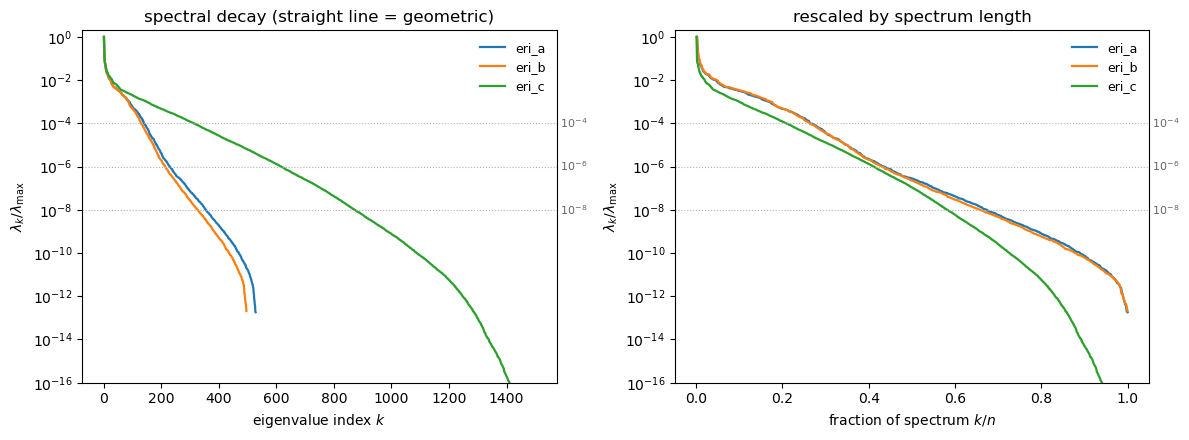

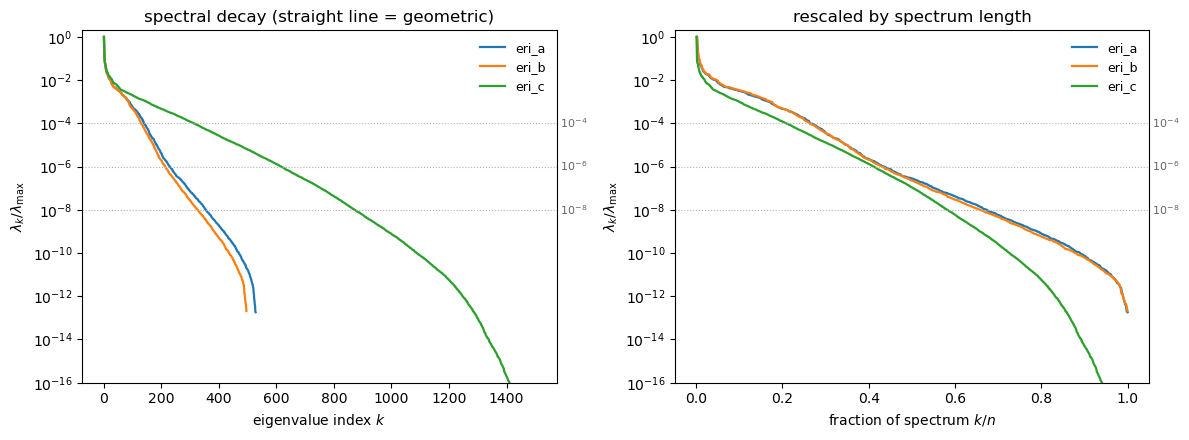

In [49]:
rng = np.random.default_rng(0)

spectra = {}
for name, L in [("a", cderi_a), ("b", cderi_b), ("c", cderi_c)]:
    ev = spectrum_from_cderi(L)
    spectra[f"eri_{name}"] = ev
    report(f"eri_{name}", L, ev)

# how much you lose by forming eri explicitly
ev_svd = spectra["eri_a"]
ev_eig = spectrum_from_eri(cderi_a)
keep = min(len(ev_svd), len(ev_eig))
dev = np.abs(ev_eig[:keep] - ev_svd[:keep]) / ev_svd[0]
print(f"\nSVD vs explicit-eri, max relative deviation: {dev.max():.2e}")
print(f"  smallest eigenvalue trusted by eigh(eri): ~{ev_svd[0] * 1e-8:.2e}")
print(f"  most negative eigenvalue from eigh(eri) : {ev_eig.min():.2e}"
        "   (should be ~0; negative = roundoff)")

plot_decay(spectra)

In [18]:
cderi_clas = jnp.array(cderi_clas)
cderi_clas = cholesky.compress_cderi_gpu(cderi_clas, thresh=chol_cut)
cderi_clas = cholesky.unpack_symmetric(cderi_clas, nclas)
cderi_a = cholesky.cderi2mo_gpu(cderi_clas, a2c)
cderi_b = cholesky.cderi2mo_gpu(cderi_clas, b2c)
cderi_a = cholesky.unpack_symmetric(cderi_a, ncas[0])
cderi_b = cholesky.unpack_symmetric(cderi_b, ncas[1])
print("Finished calculating Integrals")
print(f'LAS Alpha Cholesky shape: {cderi_a.shape}')
print(f'LAS Beta  Cholesky shape: {cderi_b.shape}')

Finished calculating Integrals
LAS Alpha Cholesky shape: (467, 32, 32)
LAS Beta  Cholesky shape: (467, 31, 31)


In [30]:
print(cderi_clas.shape)
cderi_clas = cholesky.pack_symmetric(cderi_clas)
print(cderi_clas.shape)

(467, 49, 49)
(467, 1225)


In [22]:
print(cderi_a.shape)
cderi_a = cholesky.pack_symmetric(cderi_a)
print(cderi_a.shape)

(467, 32, 32)
(467, 528)


In [24]:
chol_cut

1e-05

In [25]:
chol_a = cholesky.compress_cderi_gpu(cderi_a, thresh=chol_cut)
print(chol_a.shape)
print((np.einsum('gp,gq->pq',chol_a, chol_a) - np.einsum('gp,gq->pq',cderi_a, cderi_a)).max())

(233, 528)
1.307248096907472e-06


In [28]:
chol_a = cholesky.df2chol_cpu(cderi_a, max_error=chol_cut)
chol_a = cholesky.pack_symmetric(chol_a)
print(chol_a.shape)
print((np.einsum('gp,gq->pq',chol_a, chol_a) - np.einsum('gp,gq->pq',cderi_a, cderi_a)).max())

(228, 528)
8.0966736350635e-06


In [ ]:
eri_a = np.einsum('gp,gq->pq',cderi_a, cderi_a)
chol_a = cholesky.modified_cholesky(eri_a, max_error=chol_cut)
print(chol_a.shape)
print((np.einsum('gp,gq->pq',chol_a, chol_a) - np.einsum('gp,gq->pq',cderi_a, cderi_a)).max())

(228, 528)
8.097174093016357e-06


In [31]:
chol_c = cholesky.compress_cderi_gpu(cderi_clas, thresh=chol_cut)
print(chol_c.shape)
print((np.einsum('gp,gq->pq',chol_c, chol_c) - np.einsum('gp,gq->pq',cderi_clas, cderi_clas)).max())

(467, 1225)
2.1649348980190553e-15


In [33]:
chol_c = cholesky.df2chol_cpu(cderi_clas, max_error=chol_cut)
chol_c = cholesky.pack_symmetric(chol_c)
print(chol_c.shape)
print((np.einsum('gp,gq->pq',chol_c, chol_c) - np.einsum('gp,gq->pq',cderi_clas, cderi_clas)).max())

(448, 1225)
7.560856835567981e-06
